# Build Basic chat bot

In [16]:
from typing import Annotated
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages

In [3]:
class State(TypedDict):
    """
    Messages have the type "list". the `add_messages` function
    in the annotation defines how this state key should be updated
    (in this case, it appends messages to the list, rather than overwriting them)
    """
    messages: Annotated[list, add_messages]

graph_builder = StateGraph(State)

In [4]:
graph_builder

In [17]:
import os
from dotenv import load_dotenv

load_dotenv(override=True)

MODEL = os.getenv("OLLAMA_MODEL")

MODEL

'ollama:Gemma4'

In [7]:
from langchain.chat_models import init_chat_model

chat_model = init_chat_model(
    model=MODEL
)

chat_model

ChatOllama(metadata={'lc_versions': {'langchain-core': '1.5.3', 'langchain': '1.3.14'}}, output_version=None, model='Gemma4')

In [8]:
def chatbot(state: State):
    return {"messages": [chat_model.invoke(state["messages"])]}

In [9]:
graph_builder = StateGraph(State)
graph_builder.add_node("chatbot", chatbot)
graph_builder.add_edge(START, "chatbot")
graph_builder.add_edge("chatbot", END)

# Compile the graph
graph = graph_builder.compile()

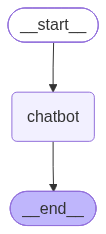

In [10]:
from IPython.display import Image, display

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except:
    pass

In [13]:
response = graph.invoke(
    {
        "messages": "Hi"
    }
)

response["messages"][-1].content

'Hello! How can I help you today? 😊'

In [15]:
for event in graph.stream({"messages": "How are you"}):
    print(event)

{'chatbot': {'messages': [AIMessage(content="I'm functioning perfectly and ready to help! I'm a large language model, so I don't experience feelings, but I can tell you that all my systems are running smoothly.\n\nHow are *you* doing today, and what can I assist you with?", additional_kwargs={}, response_metadata={'model': 'Gemma4', 'created_at': '2026-08-09T06:42:42.355925Z', 'done': True, 'done_reason': 'stop', 'total_duration': 11631794959, 'load_duration': 236783834, 'prompt_eval_count': 19, 'prompt_eval_duration': 311049000, 'eval_count': 325, 'eval_duration': 11082557000, 'logprobs': None, 'model_name': 'Gemma4', 'model_provider': 'ollama'}, id='lc_run--019fe542-3ac2-7a90-a724-5c442dd00851-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 19, 'output_tokens': 325, 'total_tokens': 344})]}}


In [18]:
from langchain_tavily import TavilySearch

tool = TavilySearch(max_result=2)
tool.invoke("What is langgraph")

{'query': 'What is langgraph',
 'follow_up_questions': None,
 'answer': None,
 'images': [],
 'results': [{'url': 'https://www.geeksforgeeks.org/machine-learning/what-is-langgraph',
   'title': 'What is LangGraph',
   'content': 'LangGraph is an open-source framework from LangChain designed to build and manage AI agent workflows using graph-based structures. It allows developers to define workflows as nodes and edges, making complex agent interactions more structured, scalable and easier to control. [...] langgraph: Framework for building graph-based AI workflows.\n langchain: Popular toolkit for LLM-powered AI applications.\n google-generativeai: Google’s API for Generative AI (Gemini models).\n\n Python  ````\n! pip install langgraph langchain google - generativeai\n```` \n\n### Step 2: Setup Gemini API [...] ## Building a Simple Chatbot with LangGraph\n\nLangGraph makes it easy to build structured, stateful applications like chatbots. In this example we’ll learn how to create a basi

In [19]:
# Custom function
def multiply(a: int, b: int) -> int:
    """
    Multiply a and b

    Args:
        a (int): first int
        b (int): second int

    Returns:
        int: output int 
    """
    return a * b

In [20]:
tools = [tool, multiply]

chat_model_with_tools = chat_model.bind_tools(tools)

In [21]:
chat_model_with_tools

_ChatModelBinding(bound=ChatOllama(metadata={'lc_versions': {'langchain-core': '1.5.3', 'langchain': '1.3.14'}}, output_version=None, model='Gemma4'), kwargs={'tools': [{'type': 'function', 'function': {'name': 'tavily_search', 'description': 'A search engine optimized for comprehensive, accurate, and trusted results. Useful for when you need to answer questions about current events. It not only retrieves URLs and snippets, but offers advanced search depths, domain management, time range filters, and image search, this tool delivers real-time, accurate, and citation-backed results.Input should be a search query.', 'parameters': {'properties': {'query': {'description': 'Search query to look up', 'type': 'string'}, 'include_domains': {'anyOf': [{'items': {'type': 'string'}, 'type': 'array'}, {'type': 'null'}], 'default': [], 'description': 'A list of domains to restrict search results to.\n\n        Use this parameter when:\n        1. The user explicitly requests information from specif

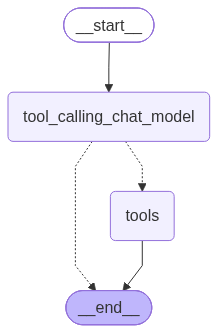

In [23]:
# Stategraph

from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode, tools_condition


## Node defination
def tool_calling_chat_model(state: State):
    return {"messages": [chat_model_with_tools.invoke(state["messages"])]}

## Graph
builder = StateGraph(State)
builder.add_node("tool_calling_chat_model", tool_calling_chat_model)
builder.add_node("tools", ToolNode(tools))

## Add Edges
builder.add_edge(START, "tool_calling_chat_model")
builder.add_conditional_edges(
    "tool_calling_chat_model",
    # if the last message (result) from assistant is a tool call -> tools_condition routes to tools
    # if the last message (result) from assistant is not a tool call -> tools_condition routest to END
    tools_condition
    )

builder.add_edge("tools", END)

## Compile the graph
graph = builder.compile()

display(Image(graph.get_graph().draw_mermaid_png()))

In [26]:
response = graph.invoke({"messages": "What is the recent news about ai?"})

In [27]:
response["messages"][-1].content

'{"query": "recent news about artificial intelligence", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://ny1.com/nyc/all-boroughs/inside-city-hall/2026/08/07/reporter-looks-at-the-latest-ai-news", "title": "Reporter looks at the latest AI news", "content": "Veronica Irwin, a senior AI policy reporter for the AI new site Transformer, joined \\"Inside City Hall.\\" (Spectrum News NY1)\\n\\n# Reporter looks at the latest AI news\\n\\nBY   Spectrum News Staff  New York City\\n\\nPUBLISHED 8:30 PM ET Aug. 07, 2026 PUBLISHED August 7, 2026 @8:30 PM\\n\\nSHARE\\n\\nArtificial intelligence was in the political headlines this week with the White House finalizing a framework for how to regulate the most advanced AI models. [...] Other recent headlines have raised profound issues of safety and security with AI models.\\n\\nVeronica Irwin, a senior AI policy reporter for the AI new site Transformer, which tracks all the latest developments in the technology, 

In [28]:
for message in response["messages"]:
    message.pretty_print()

================================ Human Message =================================

What is the recent news about ai?
================================== Ai Message ==================================
Tool Calls:
  tavily_search (3fb6d31a-60fb-4182-8a5a-4e824bbfafae)
 Call ID: 3fb6d31a-60fb-4182-8a5a-4e824bbfafae
  Args:
    query: recent news about artificial intelligence
    time_range: week
    topic: news
================================= Tool Message =================================
Name: tavily_search

{"query": "recent news about artificial intelligence", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://ny1.com/nyc/all-boroughs/inside-city-hall/2026/08/07/reporter-looks-at-the-latest-ai-news", "title": "Reporter looks at the latest AI news", "content": "Veronica Irwin, a senior AI policy reporter for the AI new site Transformer, joined \"Inside City Hall.\" (Spectrum News NY1)\n\n# Reporter looks at the latest AI news\n\nBY   Spectrum News Sta

In [29]:
response = graph.invoke({"messages": "What is 45 multiply 67"})
for m in response["messages"]:
    m.pretty_print()

================================ Human Message =================================

What is 45 multiply 67
================================== Ai Message ==================================
Tool Calls:
  multiply (9b813759-df8d-4dfd-bd96-90f90bc7cd4c)
 Call ID: 9b813759-df8d-4dfd-bd96-90f90bc7cd4c
  Args:
    a: 45
    b: 67
================================= Tool Message =================================
Name: multiply

3015


In [30]:
response = graph.invoke({"messages": "What is tha latest news about ai and then multiply 45 with 67"})
for m in response["messages"]:
    m.pretty_print()

================================ Human Message =================================

What is tha latest news about ai and then multiply 45 with 67
================================== Ai Message ==================================
Tool Calls:
  tavily_search (2096c5d6-86d1-4807-aebd-df2cddbc6a6c)
 Call ID: 2096c5d6-86d1-4807-aebd-df2cddbc6a6c
  Args:
    query: latest AI news
    time_range: day
  multiply (843caa8a-de43-4026-9d69-2155204e8d95)
 Call ID: 843caa8a-de43-4026-9d69-2155204e8d95
  Args:
    a: 45
    b: 67
================================= Tool Message =================================
Name: tavily_search

{"query": "latest AI news", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://www.cbsnews.com/sanfrancisco/tag/artificial-intelligence", "title": "Artificial Intelligence and the AI Revolution - Today's latest news and stories", "content": "#### Florida sues OpenAI over alleged harms caused by ChatGPT Florida has become the first state to s

# React Agent architecture

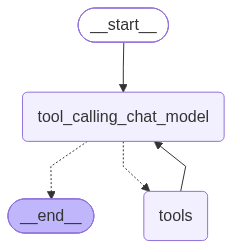

In [31]:
# Stategraph

from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode, tools_condition


## Node defination
def tool_calling_chat_model(state: State):
    return {"messages": [chat_model_with_tools.invoke(state["messages"])]}

## Graph
builder = StateGraph(State)
builder.add_node("tool_calling_chat_model", tool_calling_chat_model)
builder.add_node("tools", ToolNode(tools))

## Add Edges
builder.add_edge(START, "tool_calling_chat_model")
builder.add_conditional_edges(
    "tool_calling_chat_model",
    # if the last message (result) from assistant is a tool call -> tools_condition routes to tools
    # if the last message (result) from assistant is not a tool call -> tools_condition routest to END
    tools_condition
    )

builder.add_edge("tools", "tool_calling_chat_model")

## Compile the graph
graph = builder.compile()

display(Image(graph.get_graph().draw_mermaid_png()))

In [32]:
response = graph.invoke({"messages": "What is tha latest news about ai and then multiply 45 with 67"})
for m in response["messages"]:
    m.pretty_print()

================================ Human Message =================================

What is tha latest news about ai and then multiply 45 with 67
================================== Ai Message ==================================
Tool Calls:
  tavily_search (52012284-8cfb-4523-b5e8-4fe52a414def)
 Call ID: 52012284-8cfb-4523-b5e8-4fe52a414def
  Args:
    query: latest news about AI
    topic: news
  multiply (eb023e9f-12e4-4ebe-b1a0-4a09d24fb857)
 Call ID: eb023e9f-12e4-4ebe-b1a0-4a09d24fb857
  Args:
    a: 45
    b: 67
================================= Tool Message =================================
Name: tavily_search

{"query": "latest news about AI", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://ny1.com/nyc/all-boroughs/inside-city-hall/2026/08/07/reporter-looks-at-the-latest-ai-news", "title": "Reporter looks at the latest AI news", "content": "Veronica Irwin, a senior AI policy reporter for the AI new site Transformer, joined \"Inside City Hall.

In [33]:
response = graph.invoke({"messages": "Hello my name is Irfan"})
for m in response["messages"]:
    m.pretty_print()

================================ Human Message =================================

Hello my name is Irfan
================================== Ai Message ==================================

Hello Irfan! It's nice to meet you. How can I help you today?


In [34]:
response = graph.invoke({"messages": "What is my name?"})
for m in response["messages"]:
    m.pretty_print()

================================ Human Message =================================

What is my name?
================================== Ai Message ==================================

I do not have access to your personal information, so I do not know your name.


# Adding Memory

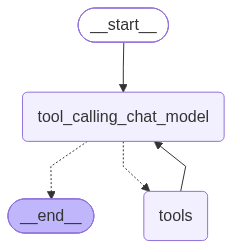

In [35]:
# Stategraph

from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode, tools_condition
from langgraph.checkpoint.memory import MemorySaver

memory = MemorySaver()

## Node defination
def tool_calling_chat_model(state: State):
    return {"messages": [chat_model_with_tools.invoke(state["messages"])]}

## Graph
builder = StateGraph(State)
builder.add_node("tool_calling_chat_model", tool_calling_chat_model)
builder.add_node("tools", ToolNode(tools))

## Add Edges
builder.add_edge(START, "tool_calling_chat_model")
builder.add_conditional_edges(
    "tool_calling_chat_model",
    # if the last message (result) from assistant is a tool call -> tools_condition routes to tools
    # if the last message (result) from assistant is not a tool call -> tools_condition routest to END
    tools_condition
    )

builder.add_edge("tools", "tool_calling_chat_model")

## Compile the graph
graph = builder.compile(checkpointer=memory)

display(Image(graph.get_graph().draw_mermaid_png()))

In [37]:
config = {"configurable": {"thread_id": "user-1"}}

response = graph.invoke({"messages": "Hi my name is Irfan"}, config=config)
response

{'messages': [HumanMessage(content='Hi my name is Irfan', additional_kwargs={}, response_metadata={}, id='87312174-8471-4679-86c7-11a17957060c'),
  AIMessage(content="Hello Irfan! It's nice to meet you. How can I help you today?", additional_kwargs={}, response_metadata={'model': 'Gemma4', 'created_at': '2026-08-09T09:17:25.832642Z', 'done': True, 'done_reason': 'stop', 'total_duration': 14684931292, 'load_duration': 2146433334, 'prompt_eval_count': 1428, 'prompt_eval_duration': 4805487000, 'eval_count': 213, 'eval_duration': 7724032000, 'logprobs': None, 'model_name': 'Gemma4', 'model_provider': 'ollama'}, id='lc_run--019fe5cf-d669-7321-8212-9331b9871ddb-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 1428, 'output_tokens': 213, 'total_tokens': 1641})]}

In [38]:
response["messages"][-1].content

"Hello Irfan! It's nice to meet you. How can I help you today?"

In [39]:
response = graph.invoke({"messages": "Hey, What is my name?"}, config=config)
response["messages"][-1].content

'Your name is Irfan.'

# Streaming

In [40]:
from langgraph.checkpoint.memory import MemorySaver

memory = MemorySaver()

In [41]:
def superbot(state: State):
    return {"messages": [chat_model_with_tools.invoke(state["messages"])]}

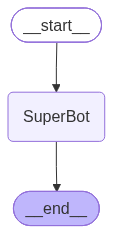

In [42]:
graph = StateGraph(State)

## Node
graph.add_node("SuperBot", superbot)

## Edges
graph.add_edge(START, "SuperBot")
graph.add_edge("SuperBot", END)

graph_builder = graph.compile(checkpointer=memory)
## Display
from IPython.display import Image, display
display(Image(graph_builder.get_graph().draw_mermaid_png()))

In [43]:
# Invocation

config = {"configurable": {"thread_id": "user-2"}}
graph_builder.invoke({"messages": "Hi, My name is Irfan and i like football"}, config=config)

{'messages': [HumanMessage(content='Hi, My name is Irfan and i like football', additional_kwargs={}, response_metadata={}, id='0fc328ef-3346-41d9-a4f8-6bbb6796c73d'),
  AIMessage(content="Hello Irfan! It's nice to meet you. ⚽️\n\nFootball is a great sport. Do you have a favorite team, league, or player that you like following? Let me know if there's anything I can help you find—like the latest scores, news about teams, or stats!", additional_kwargs={}, response_metadata={'model': 'Gemma4', 'created_at': '2026-08-09T09:28:26.226217Z', 'done': True, 'done_reason': 'stop', 'total_duration': 18823596375, 'load_duration': 2117121834, 'prompt_eval_count': 1433, 'prompt_eval_duration': 4783741000, 'eval_count': 328, 'eval_duration': 11913246000, 'logprobs': None, 'model_name': 'Gemma4', 'model_provider': 'ollama'}, id='lc_run--019fe5d9-d9e9-7330-8044-375b711b6dd3-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 1433, 'output_tokens': 328, 'total_tokens': 1761})]}

In [47]:
for chunk in graph_builder.stream({"messages": "Hi, My name is Irfan and i like football"}, config, stream_mode="updates"):
    print(chunk)

{'SuperBot': {'messages': [AIMessage(content="It sounds like you really love talking about football! 🤩 It's definitely a passionate sport.\n\nSince we keep chatting about it, perhaps you can tell me something else that excites you about the game? For example:\n\n*   **What was your favorite moment in football history so far?**\n*   **Do you prefer watching games live, or reading analyses afterward?**\n*   **Which country's style of play do you find the most exciting?** (e.g., Italian tactics, Brazilian flair, etc.)\n\nLet's talk about something fun! ⚽️", additional_kwargs={}, response_metadata={'model': 'Gemma4', 'created_at': '2026-08-09T09:38:47.670328Z', 'done': True, 'done_reason': 'stop', 'total_duration': 13234756125, 'load_duration': 245867917, 'prompt_eval_count': 1895, 'prompt_eval_duration': 526486999, 'eval_count': 357, 'eval_duration': 12455593000, 'logprobs': None, 'model_name': 'Gemma4', 'model_provider': 'ollama'}, id='lc_run--019fe5e3-6b41-7720-a804-0dc72ab2080f-0', too

In [48]:
for chunk in graph_builder.stream({"messages": "Hi, My name is Irfan and i like football"}, config, stream_mode="values"):
    print(chunk)

{'messages': [HumanMessage(content='Hi, My name is Irfan and i like football', additional_kwargs={}, response_metadata={}, id='0fc328ef-3346-41d9-a4f8-6bbb6796c73d'), AIMessage(content="Hello Irfan! It's nice to meet you. ⚽️\n\nFootball is a great sport. Do you have a favorite team, league, or player that you like following? Let me know if there's anything I can help you find—like the latest scores, news about teams, or stats!", additional_kwargs={}, response_metadata={'model': 'Gemma4', 'created_at': '2026-08-09T09:28:26.226217Z', 'done': True, 'done_reason': 'stop', 'total_duration': 18823596375, 'load_duration': 2117121834, 'prompt_eval_count': 1433, 'prompt_eval_duration': 4783741000, 'eval_count': 328, 'eval_duration': 11913246000, 'logprobs': None, 'model_name': 'Gemma4', 'model_provider': 'ollama'}, id='lc_run--019fe5d9-d9e9-7330-8044-375b711b6dd3-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 1433, 'output_tokens': 328, 'total_tokens': 1761}), HumanMe

In [49]:
config = {"configurable":{"thread_id":"user-3"}}
for chunk in graph_builder.stream({"messages": "Hi, My name is Irfan and i like cricket"}, config, stream_mode="updates"):
    print(chunk)

{'SuperBot': {'messages': [AIMessage(content="Hello Irfan! It's nice to meet you. 👋\n\nCricket is a fantastic sport! Are you following any tournaments right now? Do you have a favorite team or player that you root for? 🏏", additional_kwargs={}, response_metadata={'model': 'Gemma4', 'created_at': '2026-08-09T09:42:08.020948Z', 'done': True, 'done_reason': 'stop', 'total_duration': 11212918250, 'load_duration': 262104167, 'prompt_eval_count': 1433, 'prompt_eval_duration': 1470451000, 'eval_count': 273, 'eval_duration': 9474715000, 'logprobs': None, 'model_name': 'Gemma4', 'model_provider': 'ollama'}, id='lc_run--019fe5e6-81c6-7873-b539-72f400e7727f-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 1433, 'output_tokens': 273, 'total_tokens': 1706})]}}


In [50]:
for chunk in graph_builder.stream({"messages": "I also like football"}, config, stream_mode="values"):
    print(chunk)

{'messages': [HumanMessage(content='Hi, My name is Irfan and i like cricket', additional_kwargs={}, response_metadata={}, id='2c28931c-8afa-4211-8f0c-68e03ff9cf22'), AIMessage(content="Hello Irfan! It's nice to meet you. 👋\n\nCricket is a fantastic sport! Are you following any tournaments right now? Do you have a favorite team or player that you root for? 🏏", additional_kwargs={}, response_metadata={'model': 'Gemma4', 'created_at': '2026-08-09T09:42:08.020948Z', 'done': True, 'done_reason': 'stop', 'total_duration': 11212918250, 'load_duration': 262104167, 'prompt_eval_count': 1433, 'prompt_eval_duration': 1470451000, 'eval_count': 273, 'eval_duration': 9474715000, 'logprobs': None, 'model_name': 'Gemma4', 'model_provider': 'ollama'}, id='lc_run--019fe5e6-81c6-7873-b539-72f400e7727f-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 1433, 'output_tokens': 273, 'total_tokens': 1706}), HumanMessage(content='I also like football', additional_kwargs={}, response_meta

In [51]:
config = {"configurable":{"thread_id":"user-4"}}
async for event in graph_builder.astream_events({"messages": "Hi, My name is Irfan and i like cricket"}, config, stream_mode="updates"):
    print(event)

{'event': 'on_chain_start', 'data': {'input': {'messages': 'Hi, My name is Irfan and i like cricket'}}, 'name': 'LangGraph', 'tags': [], 'run_id': '019fe5e9-01bb-7fd0-9965-39ef3409b375', 'metadata': {'thread_id': 'user-4', 'ls_integration': 'langgraph'}, 'parent_ids': []}
{'event': 'on_chain_start', 'data': {'input': {'messages': [HumanMessage(content='Hi, My name is Irfan and i like cricket', additional_kwargs={}, response_metadata={}, id='10a3ddd1-596c-4b43-a6a7-16ee27e44b46')]}}, 'name': 'SuperBot', 'tags': ['graph:step:1'], 'run_id': '019fe5e9-01bf-7fb1-a5cc-babf0dfb0e59', 'metadata': {'thread_id': 'user-4', 'ls_integration': 'langgraph', 'langgraph_step': 1, 'langgraph_node': 'SuperBot', 'langgraph_triggers': ('branch:to:SuperBot',), 'langgraph_path': ('__pregel_pull', 'SuperBot'), 'langgraph_checkpoint_ns': 'SuperBot:0c3f5cce-b18d-5302-59e5-f24e46c13277'}, 'parent_ids': ['019fe5e9-01bb-7fd0-9965-39ef3409b375']}
{'event': 'on_chat_model_start', 'data': {'input': {'messages': [[Hum

# Human in the loop